In [8]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from lifelines import KaplanMeierFitter, CoxPHFitter
from sklearn.linear_model import BayesianRidge
from scipy.optimize import curve_fit
import pymc as pm
import arviz as az

In [9]:
data= pd.read_csv('gaia_stars_final_classification.csv')

In [10]:
main_sequence = data[data['final_phase'] == 'Main Sequence'].copy()

print(f"Found {len(main_sequence)} main sequence stars")

# Filter valid temperature range (solar-type stars)
main_sequence = main_sequence[(main_sequence['teff_gspphot'] > 3000) & 
                              (main_sequence['teff_gspphot'] < 10000)]
print(f"After temperature filtering: {len(main_sequence)} stars")

main_sequence.head()


Found 16955 main sequence stars
After temperature filtering: 16955 stars


,ra,dec,parallax,parallax_error,phot_g_mean_mag,phot_bp_mean_mag,phot_rp_mean_mag,bp_rp,radial_velocity,ruwe,teff_gspphot,phot_variable_flag,distance_pc,abs_mag,phase,cluster,gmm_cluster,dbscan_cluster,final_phase
0,251.589977,-50.638635,13.398257,0.017850,13.470652,14.585335,12.419784,2.165551,12.315269,0.951887,3730.1030,NOT_AVAILABLE,74.636572,9.105894,Main Sequence,0,0,0,Main Sequence
2,250.772902,-51.598985,10.326266,0.020964,13.695807,14.826818,12.635778,2.191039,7.051061,1.033412,3796.8080,NOT_AVAILABLE,96.840427,8.765524,Main Sequence,0,0,0,Main Sequence
5,285.774905,73.089686,13.956595,0.010605,12.161756,13.055846,11.230086,1.825760,-51.463833,1.110709,4160.7593,NOT_AVAILABLE,71.650717,7.885654,Main Sequence,0,0,0,Main Sequence
9,296.084675,70.476541,11.163278,0.013418,12.887754,13.816627,11.936210,1.880418,-9.795232,1.121394,4088.0550,NOT_AVAILABLE,89.579423,8.126713,Main Sequence,0,0,0,Main Sequence
11,285.636636,75.418511,23.857068,0.013330,12.086019,13.111851,11.080335,2.031516,-19.939575,1.135397,3422.9568,VARIABLE,41.916299,8.974104,Main Sequence,0,0,0,Main Sequence


In [11]:
# mass-temo relation: M ∝ T^{1/0.5} = T^2
solar_teff = 5772  # Solar effective temperature in Kelvin
main_sequence['mass_est'] = (main_sequence['teff_gspphot'] / solar_teff) ** 2


solar_abs_mag = 4.74  # Sun abs maginitude in G band
main_sequence['luminosity'] = 10 ** ((solar_abs_mag - main_sequence['abs_mag']) / 2.5)

##main_sequence['mass_est_ml'] = main_sequence['luminosity'] ** (1 / 3.5)


#mass estimation with scatter
def estimate_mass(luminosity):
    #Mass-luminosity relation with observational scatter
    base_mass = luminosity ** (1/3.5)
    # 10% observational scatter
    return base_mass * np.random.lognormal(0, 0.1, len(luminosity))

main_sequence['mass_est_ml'] = estimate_mass(main_sequence['luminosity'])

"""
def estimate_mass(luminosity):
    log_lum = np.log10(luminosity)
    if log_lum < -1.5:
        return 0.1 * (log_lum + 3)  # Low-mass stars
    elif log_lum < 0.5:
        return luminosity ** (1/4.0)  # Mid-mass stars
    else:
        return luminosity ** (1/3.2)  # High-mass stars

main_sequence['mass'] = main_sequence['luminosity'].apply(estimate_mass)
"""

"\ndef estimate_mass(luminosity):\n    log_lum = np.log10(luminosity)\n    if log_lum < -1.5:\n        return 0.1 * (log_lum + 3)  # Low-mass stars\n    elif log_lum < 0.5:\n        return luminosity ** (1/4.0)  # Mid-mass stars\n    else:\n        return luminosity ** (1/3.2)  # High-mass stars\n\nmain_sequence['mass'] = main_sequence['luminosity'].apply(estimate_mass)\n"

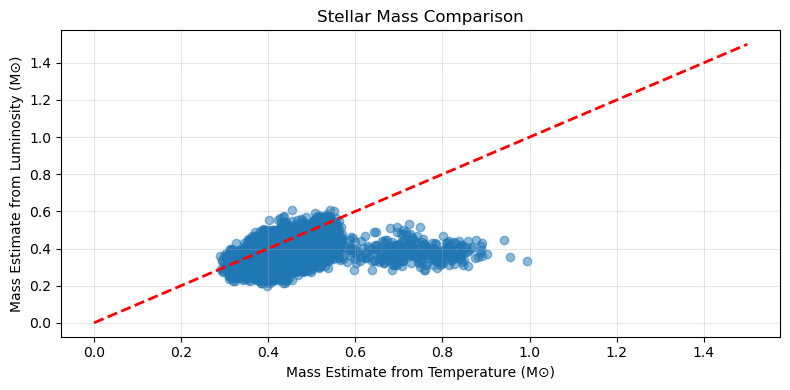

In [12]:
#Comparing estimates
plt.figure(figsize=(8, 4))
plt.scatter(main_sequence['mass_est'], main_sequence['mass_est_ml'], alpha=0.5)
plt.plot([0, 1.5], [0, 1.5], 'r--', lw=2)  # y=x line
plt.xlabel('Mass Estimate from Temperature (M⊙)')
plt.ylabel('Mass Estimate from Luminosity (M⊙)')
plt.title('Stellar Mass Comparison')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

main_sequence['mass'] = main_sequence['mass_est_ml']

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


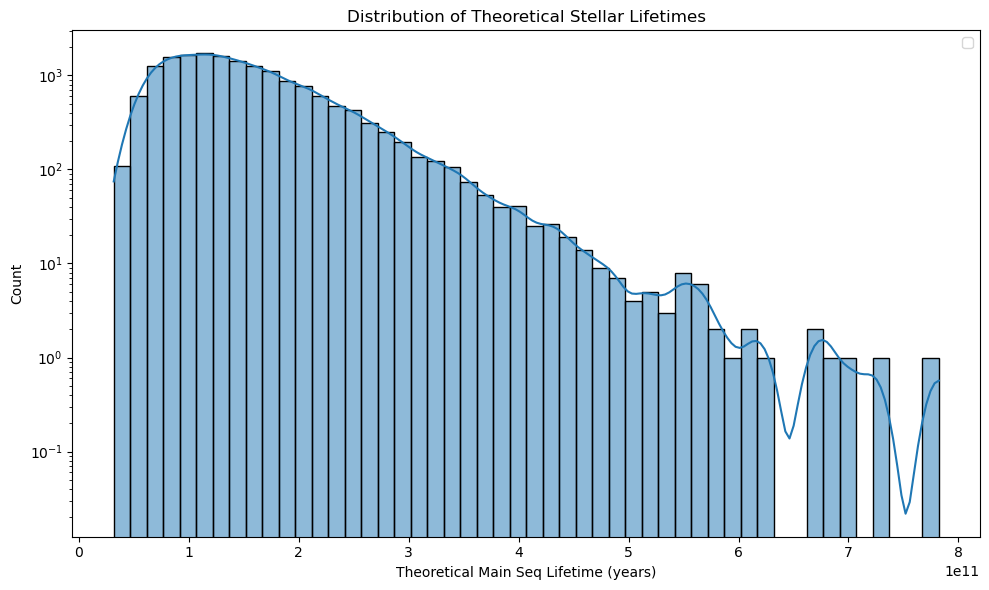

In [13]:
def theo_lifeline(mass):
    """
    Theoretical Main Sequence lifetime with scatter:
    t = 1e10 * M^{-2.5 + ε}, ε ~ N(0, 0.2)
    """
    np.random.seed(42)  # For reproducibility
    exponent = -2.5 + np.random.normal(0, 0.2, size=len(mass))
    return 1e10 * mass ** exponent

main_sequence['theo_lifetime'] = theo_lifeline(main_sequence['mass'])

plt.figure(figsize=(10, 6))
sns.histplot(main_sequence['theo_lifetime'], bins=50, kde=True)
plt.xlabel('Theoretical Main Seq Lifetime (years)')
plt.ylabel('Count')
plt.title('Distribution of Theoretical Stellar Lifetimes')
plt.legend()
plt.yscale('log')
plt.tight_layout()
plt.show()

In [18]:
# Simulate realistic stellar ages using a star formation history
np.random.seed(2025)
main_sequence['birth_time'] = np.random.uniform(0, 13.6e9, size=len(main_sequence))
main_sequence['age'] = 13.6e9 - main_sequence['birth_time']
ages = 10**np.random.uniform(np.log10(1e6), np.log10(13.6e9), len(main_sequence))
# Optional: Add mass-dependent scaling (higher mass stars evolve faster)
main_sequence['age'] = main_sequence['age'] * (main_sequence['mass'] ** 0.7)

# Define event: 1 if star has left the Main Sequence
main_sequence['event'] = (main_sequence['age'] > main_sequence['theo_lifetime']).astype(int)

# Cap theoretical lifetime at the age of the universe (for survival analysis)
max_lifeline = 13.6e9 * (main_sequence['mass']/0.8)**3
main_sequence['theo_lifetime'] = np.minimum(main_sequence['theo_lifetime'], max_lifeline)

# Duration is the minimum of observed age and theoretical lifetime
main_sequence['duration'] = np.minimum(main_sequence['age'], main_sequence['theo_lifetime'])

# Show fraction of evolved stars
print(f"Fraction of stars that have left main sequence: {main_sequence['event'].mean():.2%}")

Fraction of stars that have left main sequence: 81.24%


In [19]:
print("Mass statistics:")
print(main_sequence['mass'].describe())

Mass statistics:
count    16955.000000
mean         0.356553
std          0.059825
min          0.198714
25%          0.311146
50%          0.348084
75%          0.395395
max          0.606966
Name: mass, dtype: float64


In [20]:
# Check minimum lifetime
min_lifetime = main_sequence['theo_lifetime'].min()
max_age = main_sequence['age'].max()
print(f"\nMinimum theoretical lifetime: {min_lifetime:.2e} years")
print(f"Maximum assigned age: {max_age:.2e} years")
print(f"Is min_lifetime > max_age? {min_lifetime > max_age}")


Minimum theoretical lifetime: 2.08e+08 years
Maximum assigned age: 8.73e+09 years
Is min_lifetime > max_age? False


Min mass: 0.20 M⊙
Max mass: 0.61 M⊙
Fraction with event: 81.24%


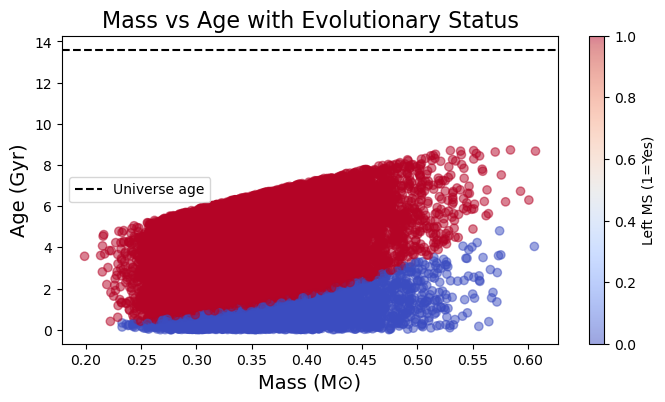

In [21]:
print(f"Min mass: {main_sequence['mass'].min():.2f} M⊙")
print(f"Max mass: {main_sequence['mass'].max():.2f} M⊙")
print(f"Fraction with event: {main_sequence['event'].mean():.2%}")

# Plot mass vs age
plt.figure(figsize=(8,4))
plt.scatter(main_sequence['mass'], main_sequence['age']/1e9, 
            c=main_sequence['event'], cmap='coolwarm', alpha=0.5)
plt.axhline(13.6, color='k', linestyle='--', label='Universe age')
plt.xlabel('Mass (M⊙)', fontsize=14)
plt.ylabel('Age (Gyr)', fontsize=14)
plt.title('Mass vs Age with Evolutionary Status', fontsize=16)
plt.colorbar(label='Left MS (1=Yes)')
plt.legend()
plt.show()

### KM Model

In [22]:
kmf = KaplanMeierFitter()

kmf.fit(durations=main_sequence['duration'],
        event_observed=main_sequence['event'],
        label='All Main Sequence Stars')

<lifelines.KaplanMeierFitter:"All Main Sequence Stars", fitted with 16955 total observations, 3180 right-censored observations>

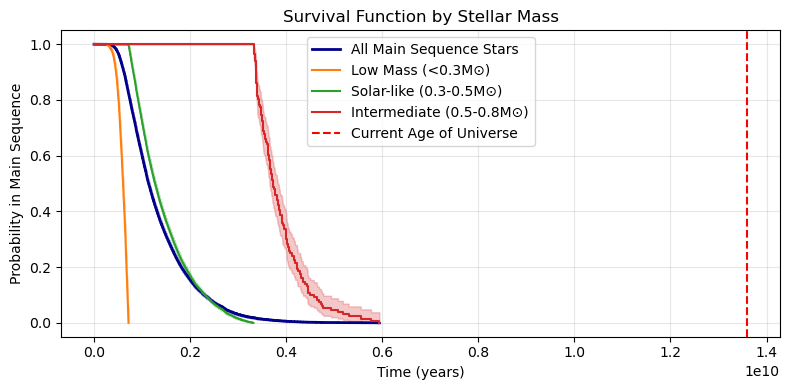

In [23]:
mass_bins = [0, 0.3, 0.5, 0.8, 2]
#mass_bins = np.linspace(0.1, 1.5, 20)
labels = ['Low Mass (<0.3M⊙)', 'Solar-like (0.3-0.5M⊙)', 
          'Intermediate (0.5-0.8M⊙)', 'High Mass (>0.8M⊙)']

plt.figure(figsize=(8, 4))

kmf.plot_survival_function(linewidth=2, color='darkblue')

for i in range(len(mass_bins)-1):
    mask = (main_sequence['mass'] > mass_bins[i]) & (main_sequence['mass'] <= mass_bins[i+1])
    grup_data = main_sequence[mask]
    
    if len(grup_data) > 0:
        kmf.fit(durations=grup_data['duration'],
                event_observed=grup_data['event'],
                label=labels[i])
        kmf.plot_survival_function()

plt.axvline(13.6e9, color='red', linestyle='--', label='Current Age of Universe')
plt.xlabel('Time (years)')
plt.ylabel('Probability in Main Sequence')
plt.title('Survival Function by Stellar Mass')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [24]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [25]:
#Prepare data for Cox model 
cox_data = main_sequence[['duration', 'event', 'mass', 'teff_gspphot']].copy()

cox_data.rename(columns={
    'duration' : 'T',
    'event' : 'E'
}, inplace=True)

# Standardize features
cox_data[['mass', 'teff_gspphot']] = scaler.fit_transform(cox_data[['mass', 'teff_gspphot']])

# Cox model
cph = CoxPHFitter()
cph.fit(cox_data, duration_col='T', event_col='E')

/opt/anaconda3/lib/python3.12/site-packages/lifelines/fitters/coxph_fitter.py:1614: ConvergenceWarning: Newton-Raphson failed to converge sufficiently. Please see the following tips in the lifelines documentation: https://lifelines.readthedocs.io/en/latest/Examples.html#problems-with-convergence-in-the-cox-proportional-hazard-model
  warnings.warn(


<lifelines.CoxPHFitter: fitted with 16955 total observations, 3180 right-censored observations>

In [26]:
# Display results
print("Cox Proportional Hazards Model Results:")
cph.print_summary()
print("\nInterpretation:")
print("Hazard ratio <1 means lower risk of leaving main sequence")
print("Hazard ratio >1 means higher risk of leaving main sequence")

Cox Proportional Hazards Model Results:


<lifelines.CoxPHFitter: fitted with 16955 total observations, 3180 right-censored observations>
             duration col = 'T'
                event col = 'E'
      baseline estimation = breslow
   number of observations = 16955
number of events observed = 13775
   partial log-likelihood = -78635.09
         time fit was run = 2025-07-31 11:27:14 UTC

---
               coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                      
mass         -12.06      0.00      0.10          -12.26          -11.85                0.00                0.00
teff_gspphot   0.01      1.01      0.01           -0.01            0.03                0.99                1.03

              cmp to       z      p  -log2(p)
covariate                                    
mass            0.00 -116.31 <0.005       inf
teff_gspphot    0.00    0.67   0.50      0.99
---
Concordance = 1.00
Partial AIC = 157274.19
log-likelihood ratio test = 80767.21 on 2 df
-log2(p) of ll-ratio test = inf


Interpretation:
Hazard ratio <1 means lower risk of leaving main sequence
Hazard ratio >1 means higher risk of leaving main sequence


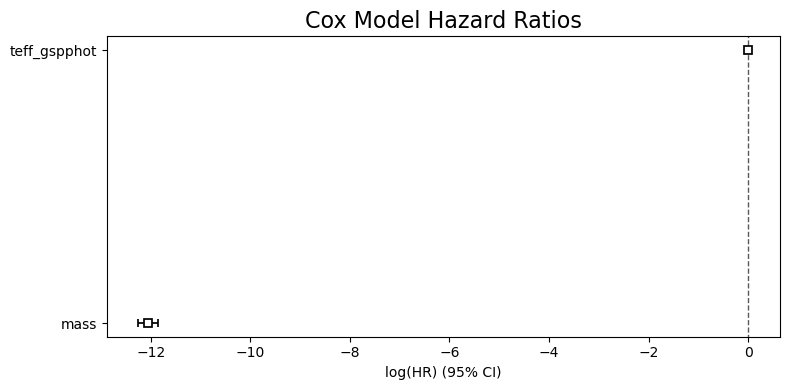

In [27]:
# Plot coefficients
plt.figure(figsize=(8, 4))
cph.plot()
plt.title('Cox Model Hazard Ratios', fontsize=16)
plt.tight_layout()
plt.show()

In [28]:
from lifelines import WeibullAFTFitter, LogNormalAFTFitter

In [29]:
aft_data = (
    main_sequence
    .assign(log_mass=np.log(main_sequence['mass']))     # linearizes the power-law relationship
    .loc[:, ['duration', 'event', 'log_mass', 'teff_gspphot']]
    .copy()
)

#aft_data = main_sequence[['duration', 'event', 'mass', 'luminosity', 'teff_gspphot']].copy()

# Rename for Cox model
aft_data.rename(columns={'duration': 'T', 'event': 'E'}, inplace=True)


# Add small observational noise to avoid perfect prediction
np.random.seed(234)
aft_data['log_mass'] += np.random.normal(0, 0.05, len(aft_data))  # small normal noise

# Standardize features
#aft_data[['log_mass', 'teff_gspphot']] = scaler.fit_transform(aft_data[['log_mass', 'teff_gspphot']])
# ensuring the AFT model interprets the direction correctly
aft_data['log_mass'] = -aft_data['log_mass']

In [30]:
aft = WeibullAFTFitter()
aft.fit(aft_data, duration_col='T', event_col='E')
aft.print_summary()

<lifelines.WeibullAFTFitter: fitted with 16955 total observations, 3180 right-censored observations>
             duration col = 'T'
                event col = 'E'
   number of observations = 16955
number of events observed = 13775
           log-likelihood = -281040.33
         time fit was run = 2025-07-31 11:27:51 UTC

---
                      coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
param   covariate                                                                                                     
lambda_ log_mass     -2.63      0.07      0.01           -2.64           -2.61                0.07                0.07
        teff_gspphot  0.00      1.00      0.00            0.00            0.00                1.00                1.00
        Intercept    23.16  1.14e+10      0.03           23.11           23.21            1.09e+10            1.21e+10
rho_    Intercept     1.97      7.16      0.01            1.96            1.98                7.07                7.24

                      cmp to       z      p  -log2(p)
param   covariate                                    
lambda_ log_mass        0.00 -320.26 <0.005       inf
        teff_gspphot    0.00   25.17 <0.005    461.87
        Intercept       0.00  873.31 <0.005       inf
rho_    Intercept       0.00  331.56 <0.005       inf
---
Concordance = 0.92
AIC = 562088.66
log-likelihood ratio test = 36424.18 on 2 df
-log2(p) of ll-ratio test = inf

In [31]:
ln_aft = LogNormalAFTFitter()
ln_aft.fit(aft_data, duration_col='T', event_col='E')
ln_aft.print_summary()

<lifelines.LogNormalAFTFitter: fitted with 16955 total observations, 3180 right-censored observations>
             duration col = 'T'
                event col = 'E'
   number of observations = 16955
number of events observed = 13775
           log-likelihood = -279900.89
         time fit was run = 2025-07-31 11:27:56 UTC

---
                     coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
param  covariate                                                                                                     
mu_    log_mass     -2.64      0.07      0.01           -2.66           -2.63                0.07                0.07
       teff_gspphot  0.00      1.00      0.00            0.00            0.00                1.00                1.00
       Intercept    23.17  1.15e+10      0.03           23.12           23.22            1.10e+10            1.21e+10
sigma_ Intercept    -1.95      0.14      0.01           -1.97           -1.94                0.14                0.14

                     cmp to       z      p  -log2(p)
param  covariate                                    
mu_    log_mass        0.00 -323.02 <0.005       inf
       teff_gspphot    0.00   23.86 <0.005    415.43
       Intercept       0.00  925.60 <0.005       inf
sigma_ Intercept       0.00 -326.44 <0.005       inf
---
Concordance = 0.92
AIC = 559809.79
log-likelihood ratio test = 36064.46 on 2 df
-log2(p) of ll-ratio test = inf

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [a, b, sigma]


Output()

Sampling 2 chains for 1_000 tune and 2_000 draw iterations (2_000 + 4_000 draws total) took 46 seconds.
There were 12 divergences after tuning. Increase `target_accept` or reparameterize.
We recommend running at least 4 chains for robust computation of convergence diagnostics


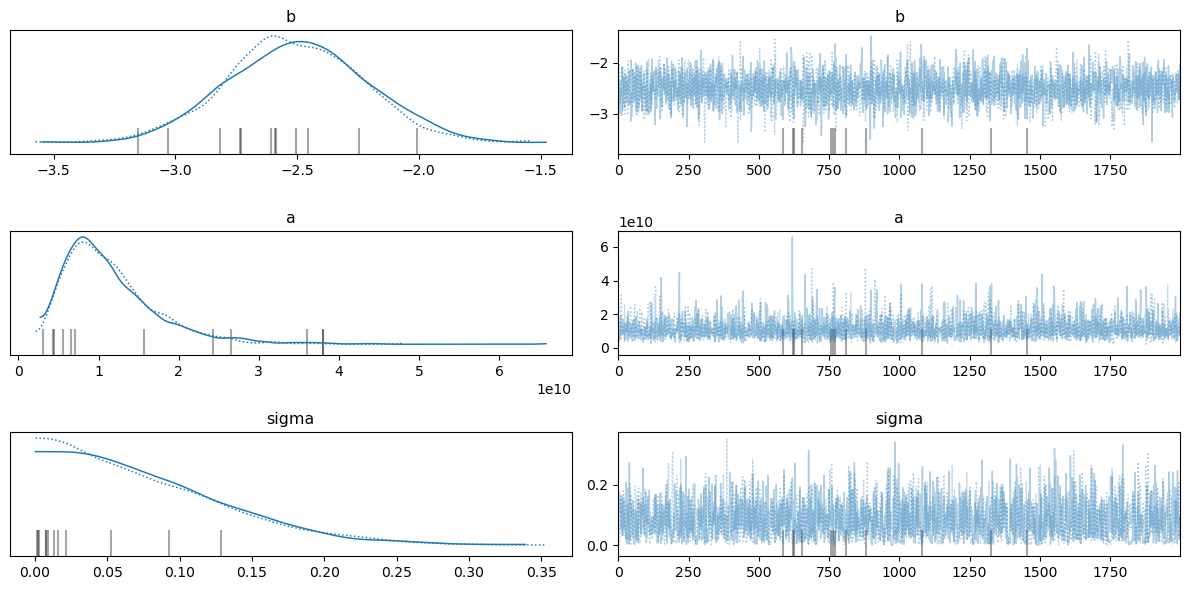

In [32]:
# Extract data
masses = main_sequence['mass'].values
ages = main_sequence['age'].values
events = main_sequence['event'].values  # 1 = left MS, 0 = still on MS

with pm.Model() as lifetime_model:
    # Priors
    a = pm.LogNormal('a', mu=np.log(1e10), sigma=0.5)
    b = pm.Normal('b', mu=-2.5, sigma=0.3)
    sigma = pm.HalfNormal('sigma', sigma=0.1)

    # Predicted lifetime (power law)
    predicted_lifetime = a * masses**b

    # Log-normal distribution for lifetime
    log_lifetime_dist = pm.LogNormal.dist(mu=pm.math.log(predicted_lifetime), sigma=sigma)

    # Censoring:
    # - event == 1 → left-censored (lifetime < age)
    # - event == 0 → right-censored (lifetime > age)

    # Use pm.Censored to define the censored likelihood
    censored_obs = pm.Censored("censored_obs", log_lifetime_dist, lower=None, upper=ages, observed=ages)

    # Sample
    trace = pm.sample(2000, tune=1000, cores=2, target_accept=0.9)
    #trace = pm.sample(2000, tune=1000, cores=2, return_inferencedata=True)

# Visualize results
az.plot_trace(trace)
plt.tight_layout()
plt.show()


In [33]:
summary = az.summary(trace)
print("\nBayesian Power Law Fit Summary:")
print(summary)


Bayesian Power Law Fit Summary:
               mean            sd        hdi_3%       hdi_97%     mcse_mean  \
b     -2.505000e+00  2.880000e-01 -3.032000e+00 -1.950000e+00  6.000000e-03   
a      1.143929e+10  5.942682e+09  2.882458e+09  2.177048e+10  1.061876e+08   
sigma  7.800000e-02  5.900000e-02  0.000000e+00  1.840000e-01  1.000000e-03   

            mcse_sd  ess_bulk  ess_tail  r_hat  
b      5.000000e-03    2713.0    2149.0    1.0  
a      1.520471e+08    3314.0    2505.0    1.0  
sigma  1.000000e-03    1586.0    1525.0    1.0  


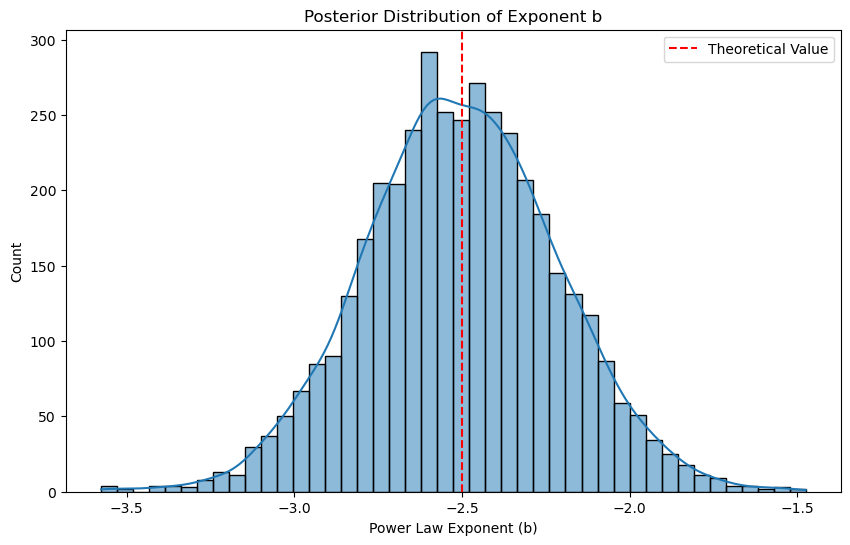

In [36]:
plt.figure(figsize=(10, 6))
sns.histplot(trace.posterior['b'].values.flatten(), kde=True)
plt.axvline(-2.5, color='r', linestyle='--', label='Theoretical Value')
plt.xlabel('Power Law Exponent (b)')
plt.title('Posterior Distribution of Exponent b')
plt.legend()
plt.show()

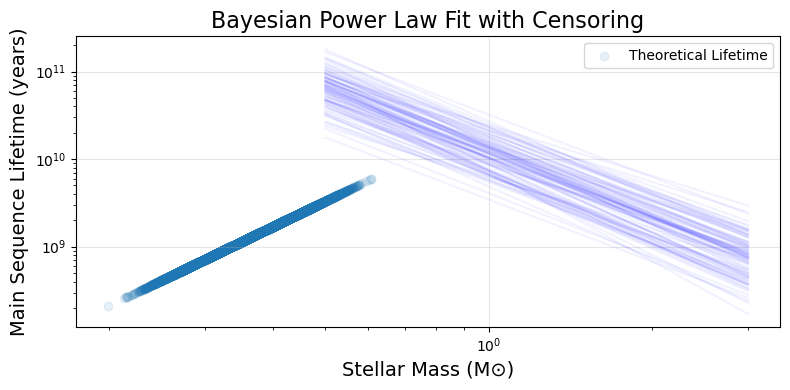

In [34]:
plt.figure(figsize=(8,4))
plt.scatter(masses, main_sequence['theo_lifetime'], 
            alpha=0.1, label = "Theoretical Lifetime")

#Posterior Predictions
mass_range = np.linspace(0.5, 3, 100)

a_samples = trace.posterior['a'].values.flatten()  # shape: (n_samples,)
b_samples = trace.posterior['b'].values.flatten()

posterior = trace.posterior  # Access posterior group
for i in range(100):
    a_sample = a_samples[np.random.randint(len(a_samples))]
    b_sample = b_samples[np.random.randint(len(b_samples))]
    plt.plot(mass_range, 
             a_sample * mass_range ** b_sample,
             color='blue', alpha=0.05)
    
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Stellar Mass (M⊙)', fontsize=14)
plt.ylabel('Main Sequence Lifetime (years)', fontsize=14)
plt.title('Bayesian Power Law Fit with Censoring', fontsize=16)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [38]:
from astropy.coordinates import SkyCoord
import astropy.units as u

In [ ]:
# ---
# ## Metallicity Proxy Analysis
# ---
# Use galactic position as metallicity proxy
# Convert to galactic coordinates
coords = SkyCoord(ra=data['ra']*u.degree, dec=data['dec']*u.degree, frame='icrs')
galactic = coords.galactic

# Add to dataframe
data['gal_lon'] = galactic.l.deg
data['gal_lat'] = galactic.b.deg

# Height above galactic plane as metallicity proxy
data['height_pc'] = data['distance_pc'] * np.sin(np.radians(data['gal_lat']))

# Bin by height
height_bins = [-300, -100, 100, 300]
labels = ['Thick Disk (Low Z)', 'Thin Disk (Mid Z)', 'Halo (High Z)']

# Survival analysis by height group
plt.figure(figsize=(12, 8))
for i in range(len(height_bins)-1):
    mask = (data['height_pc'] > height_bins[i]) & (data['height_pc'] <= height_bins[i+1])
    group = data[mask]
    
    # Only consider main sequence stars
    ms_group = group[group['final_phase'] == 'Main Sequence']
    
    if len(ms_group) > 100:  # Minimum group size
        kmf.fit(ms_group['duration'], 
                event_observed=ms_group['event'],
                label=labels[i])
        kmf.plot_survival_function()

plt.axvline(13.6e9, color='k', linestyle='--', label='Age of Universe')
plt.title('Main Sequence Survival by Galactic Height')
plt.xlabel('Time (years)')
plt.ylabel('Survival Probability')
plt.legend()
plt.show()

UnitTypeError: Angle instances require units equivalent to 'rad', but no unit was given.